# Implement folder Planck equation


In [1]:
import numpy as np
import torch
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import os, warnings
import numpy as np
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", category=UserWarning,
                        message="KMP_DUPLICATE_LIB_OK")
import numpy as np
import pandas as pd
import numpy as np
import copy

from fokker_planck import run_fp, plot_fp_density_time_dim, N_I, LAM, KBT, E_A, N_MAX, V_ADV, D


# Least actions

In [2]:
def make_grad_Gamma(fp_ctx):
    times, grads = fp_ctx["times"], fp_ctx["grad_list"]
    def grad(h, t):
        if t <= times[0]:  return grads[0](h)
        if t >= times[-1]: return grads[-1](h)
        hi = np.searchsorted(times, t)
        lo = hi - 1
        w  = (t-times[lo])/(times[hi]-times[lo])
        return (1.-w)*grads[lo](h) + w*grads[hi](h)
    return grad

from scipy.integrate import solve_bvp

def solve_optimal_trajectory(
        hf, fp_ctx, *, mesh=1000, max_nodes=20_000, plot=False):
    """
    Computes the least-action trajectory from h(t0)=0 to h(tf)=hf.
    Works for arbitrary dimensionality N = fp_ctx["S_mat"].shape[0].
    """
    # ---------------- basic info ----------------
    times   = fp_ctx["times"]
    grad_G  = make_grad_Gamma(fp_ctx)
    t0, tf  = times[0], times[-1]
    N       = fp_ctx["S_mat"].shape[0]          # number of h coordinates

    # ------------- final boundary vector -------------
    if np.isscalar(hf):
        hf = np.repeat(float(hf), N)            # same target for every dim
    else:
        hf = np.asarray(hf, dtype=float)
        if hf.size != N:
            raise ValueError(
                f"hf must have length {N} (one per shape dim); got {hf.size}")

    # ----------------- ODE system --------------------
    # state y = (h, v)  ⇒  size 2N
    def ode(t, y):
        h, v = y[:N], y[N:]                      # each is shape (N, len(t))
        a    = np.empty_like(h)
        for j, tj in enumerate(t):               # loop over mesh points
            a[:, j] = -D * grad_G(h[:, j], tj)   # acceleration
        return np.vstack((v, a))

    # ------------- boundary conditions --------------
    def bc(ya, yb):
        # ya[:N]  : h(t0)  ;  yb[:N] : h(tf)
        return np.hstack((ya[:N], yb[:N] - hf))

    # ------------- initial mesh & guess -------------
    t_mesh  = np.linspace(t0, tf, mesh)
    y_guess = np.zeros((2 * N, mesh))
    for i in range(N):                           # linear interpolation guess
        y_guess[i] = hf[i] * (t_mesh - t0) / (tf - t0)

    # ------------- solve BVP ------------------------
    sol = solve_bvp(ode, bc, t_mesh, y_guess, max_nodes=max_nodes)
    if not sol.success:
        raise RuntimeError(sol.message)

    # ------------- optional plot --------------------
    if plot:
        plt.figure(figsize=(6, 3))
        for i in range(N):
            plt.plot(sol.x, sol.y[i], label=r"$Affinity $(-E(h))$")
        plt.xlabel("GC rounds (12h)")
        plt.ylabel("shape coordinate")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return sol


def compute_least_action(sol, fp_ctx, *, baseline=True, verbose=False):
    """
    Return S_opt   (and S_lin when baseline=True)
    Compatible with any number N = S_mat.shape[0] of shape coordinates.
    """
    # ------------------------------------------------------------------
    times   = fp_ctx["times"]
    omegas  = fp_ctx["omegas"]
    Phi_bar = fp_ctx["Phi_bar"]
    get_C   = fp_ctx["get_C"]
    S_mat   = fp_ctx["S_mat"]
    n_A     = S_mat.shape[1]
    N       = S_mat.shape[0]               # number of h coordinates

    # constants (assumed already defined in the notebook)
    v_vec   = V_ADV * np.ones(N)     # deterministic drift term

    # --- torch version of S_mat for Γ --------------------------------
    S_T     = torch.tensor(S_mat, dtype=torch.float64)

    # -------------------- Γ(t, h) ------------------------------------
    def Γ(t, h_np):
        """
        Growth rate minus omega at time t and shape h (numpy array length N).
        Returns a scalar float.
        """
        # match given t to nearest entry in 'times'
        k      = int(np.argmin(np.abs(times - t)))
        omega  = omegas[k]
        Phi_b  = Phi_bar[k]

        C_vec  = np.array([get_C(float(times[k]), v) for v in range(n_A)],
                          dtype=float)

        # torch variables
        h_t = torch.tensor(h_np, dtype=torch.float64)
        C_t = torch.tensor(C_vec, dtype=torch.float64)

        # energy of each antigen
        E_v = torch.mv(S_T.T, h_t)         # shape (n_A,)

        # binding probability to target antigen
        PAg = (C_t * torch.exp((E_v - E_A) / KBT)).sum()
        PAg = PAg / (1.0 + PAg)

        # total binding probability (any antigen)
        Phi = (torch.exp(E_v / KBT)).sum()
        PT  = Phi / (Phi + Phi_b / C_t.sum())

        return (LAM + torch.log(PAg) + torch.log(PT) - omega).item()

    # ----------------- extract optimal traj ---------------------------
    t_mesh = sol.x                       # shape (m,)
    h_opt  = sol.y[:N].T                 # shape (m, N)
    v_opt  = sol.y[N:2*N].T              # shape (m, N)

    # ----------------- action functional ------------------------------
    def S_of(h, v):
        g    = np.array([Γ(ti, hi) for ti, hi in zip(t_mesh, h)])
        kin  = np.sum((v - v_vec) ** 2, axis=1) / (2 * D)
        return -np.trapz(g - kin, t_mesh)

    S_opt = S_of(h_opt, v_opt)
    if not baseline:
        if verbose:
            print(f"S_opt = {S_opt:.6e}")
        return S_opt

    # ---------------- linear baseline trajectory ----------------------
    slope  = h_opt[-1] / (t_mesh[-1] - t_mesh[0])      # vector length N
    h_lin  = (t_mesh[:, None] - t_mesh[0]) * slope[None, :]
    v_lin  = np.tile(slope, (len(t_mesh), 1))
    S_lin  = S_of(h_lin, v_lin)

    if verbose:
        print(f"S_opt = {S_opt:.6e}   S_lin = {S_lin:.6e}   ΔS = {S_lin - S_opt:.6e}")

    return S_opt, S_lin


# Finite diff gradient


In [3]:
import numpy as np
import copy

def compute_action_and_gradients(C_inj, t_inj, target_hf, tau=20.0, T=140.0, basal_C=1e-12, epsilon=1):
    """
    Computes the least action S and its finite difference gradients with respect to
    vaccine doses (C_inj) and injection times (t_inj).
    
    Returns:
        action (float): The least action S.
        grad_C_inj (np.ndarray): Finite difference gradient of S with respect to doses.
        grad_t_inj (np.ndarray): Finite difference gradient of S with respect to injection times.
    """
    C_inj = np.array(C_inj, dtype=float)
    t_inj = np.array(t_inj, dtype=float)
    
    # Helper function to compute just the action for a given set of parameters
    def get_action_for_params(c_params, t_params):
        def get_C_func(t, v=0, *args):
            t_arr = np.atleast_1d(t)
            C_total = np.full_like(t_arr, basal_C, dtype=float)
            for ci, ti in zip(c_params, t_params):
                mask = t_arr >= ti
                C_total[mask] += ci * np.exp(-(t_arr[mask] - ti) / tau)
            return C_total[0] if np.isscalar(t) else C_total

        # Compute population evolution
        fp_ctx = run_fp(get_C=get_C_func, T=T, verbose=False)
        fp_ctx_safe = copy.deepcopy(fp_ctx)
        
        # Compute least action trajectory
        sol = solve_optimal_trajectory([target_hf], fp_ctx_safe)
        action_val, _ = compute_least_action(sol, fp_ctx_safe, verbose=False)
        
        return action_val

    # 1. Compute Base Action
    base_action = get_action_for_params(C_inj, t_inj)
    
    grad_C_inj = np.zeros_like(C_inj)
    grad_t_inj = np.zeros_like(t_inj)
    
    # 2. Compute Finite Difference Gradients for C_inj
    for i in range(len(C_inj)):
        C_inj_eps = np.copy(C_inj)
        C_inj_eps[i] += epsilon
        
        action_eps = get_action_for_params(C_inj_eps, t_inj)
        grad_C_inj[i] = (action_eps - base_action) / epsilon
        
    # 3. Compute Finite Difference Gradients for t_inj
    for i in range(len(t_inj)):
        if i==0:
            grad_t_inj[i]=0
            continue
        t_inj_eps = np.copy(t_inj)
        t_inj_eps[i] += epsilon
        
        action_eps = get_action_for_params(C_inj, t_inj_eps)
        grad_t_inj[i] = (action_eps - base_action) / epsilon
        
    return base_action, grad_C_inj, grad_t_inj

In [4]:
import numpy as np

def run_optimization_loop(C_inj_init, t_inj_init, target_hf, num_iterations=50, lr_C=5, lr_t=1, tau=20.0, T=140.0, basal_C=1e-12):
    """
    Optimizes vaccine doses (C_inj) and injection times (t_inj) using gradient descent,
    calling the standalone compute_action_and_gradients function at each step.
    
    Returns:
        C_inj (np.ndarray): Optimized doses.
        t_inj (np.ndarray): Optimized injection times.
        history (list): History of action values to track convergence.
    """
    C_inj = np.array(C_inj_init, dtype=float)
    t_inj = np.array(t_inj_init, dtype=float)
    
    history = []
    
    for step in range(num_iterations):
        print(f"--- Iteration {step+1}/{num_iterations} ---")
        print(f"Current Doses: {C_inj}")
        print(f"Current Times: {t_inj}")
        
        # 1. Compute action and gradients using the encapsulated function
        action, grad_C_inj, grad_t_inj = compute_action_and_gradients(
            C_inj, t_inj, target_hf, tau=tau, T=T, basal_C=basal_C
        )
        
        # Store action and copies of current parameters
        history.append({
            'action': action,
            'C_inj': C_inj.copy(),
            't_inj': t_inj.copy()
        })
        
        print(f"Least action S = {action:.6e}")
        print(f"Gradient w.r.t C_inj: {grad_C_inj}")
        print(f"Gradient w.r.t t_inj: {grad_t_inj}")
        
        # 2. Safeguards: Clip gradients to prevent massive updates and stiffness
        grad_C_inj_clipped = np.clip(grad_C_inj, -50.0, 50.0)
        grad_t_inj_clipped = np.clip(grad_t_inj, -50.0, 50.0)
        
        # 3. Apply parameter updates
        C_inj -= lr_C * grad_C_inj_clipped
        t_inj -= lr_t * grad_t_inj_clipped
        
        # 4. Impose constraints and physical boundaries
        # Keep the first injection time strictly fixed
        t_inj[0] = t_inj_init[0] 
        
        # Impose physical boundaries (safely above 0 to avoid 1/C explosions)
        C_inj = np.maximum(C_inj, 1e-3)
        t_inj = np.clip(t_inj, 0.0, T)
        
    print("\n" + "="*40)
    print("=== OPTIMIZATION COMPLETE ===")
    print("="*40)
    print(f"Final Doses: {C_inj}")
    print(f"Final Times: {t_inj}")
    
    return C_inj, t_inj, history

In [5]:
C_inj_initial = np.array([91.24023, 44.56984])   # Initial guesses for doses
t_inj_initial = np.array([ 0.,76.80806])  # Initial guesses for injection times
target_hf = 30

# # Call the optimization loop
# optimized_C, optimized_t, history = run_optimization_loop(
#     C_inj_init=C_inj_initial,
#     t_inj_init=t_inj_initial,
#     target_hf=target_hf,
#     num_iterations=50,
#     lr_C=20.0,
#     lr_t=1.0,
#     tau=20.0,
#     T=140.0
# )

# print("Optimized Doses:", optimized_C)
# print("Optimized Injection Times:", optimized_t)



In [ ]:
results_dir = "vaccine_optim_results_1_5"


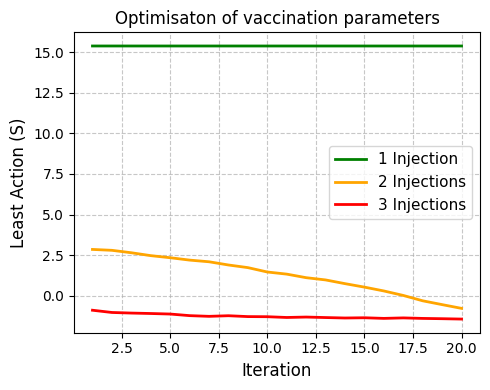

In [23]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Configuration
target_hf = 30
tau=20.0
colors_inj = {1: 'green', 2: 'orange', 3: 'red'}
labels_inj = {1: '1 Injection', 2: '2 Injections', 3: '3 Injections'}

plt.figure(figsize=(5, 4))

for ninj in [1, 2, 3]:
    # Check both int and float formatting just in case
    file_int = os.path.join(results_dir, f"optimization_history_hf_{target_hf}_ninj_{ninj}_tau_{tau}.csv")
    file_float = os.path.join(results_dir, f"optimization_history_hf_{float(target_hf)}_ninj_{ninj}_tau_{tau}.csv")
    
    filepath = file_int if os.path.exists(file_int) else file_float
    
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        plt.plot(
            df['iteration'], 
            df['action'], 
            color=colors_inj[ninj], 
            label=labels_inj[ninj], 
            linewidth=2
        )
    else:
        print(f"Warning: Could not find data file for {ninj} injection(s). Looked for: {filepath}")

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Least Action (S)', fontsize=12)
plt.title('Optimisaton of vaccination parameters')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot
# plt.savefig(os.path.join(results_dir, f"action_vs_iteration_hf{target_hf}.png"), dpi=300)
plt.show()

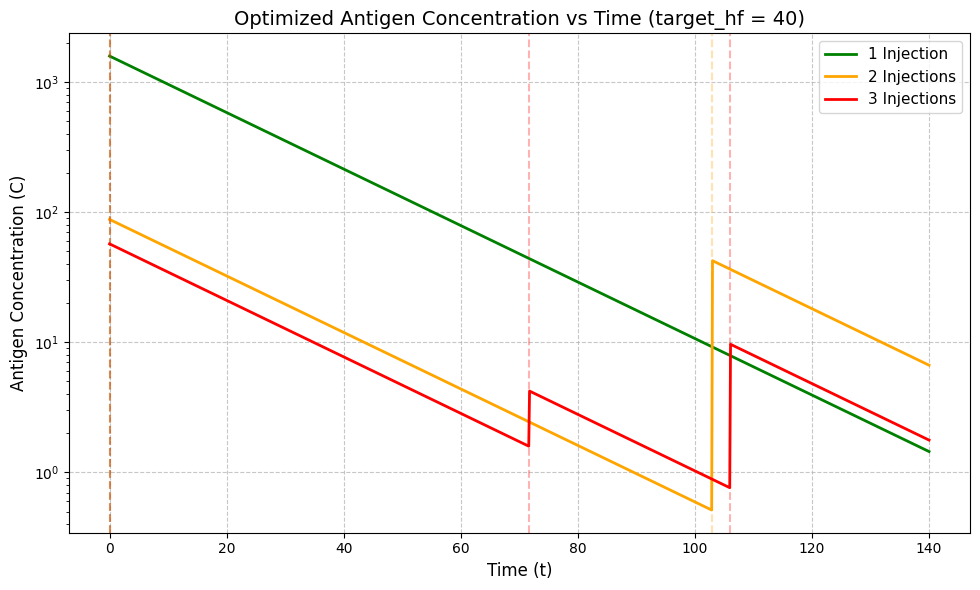

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuration
target_hf = 40
tau = 20.0
T = 140.0
basal_C = 1e-12

colors_inj = {1: 'green', 2: 'orange', 3: 'red'}
labels_inj = {1: '1 Injection', 2: '2 Injections', 3: '3 Injections'}

# Time array for plotting
t_arr = np.linspace(0, T, 1000)

plt.figure(figsize=(10, 6))
for ninj in [1, 2, 3]:
    # Check both int and float formatting
    file_int = os.path.join(results_dir, f"optimized_params_hf_{target_hf}_ninj_{ninj}_tau_{tau}.csv")
    file_float = os.path.join(results_dir, f"optimized_params_hf_{float(target_hf)}_ninj_{ninj}_tau_{tau}.csv")
    
    filepath = file_int if os.path.exists(file_int) else file_float
    
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        c_params = df['dose_C'].values
        t_params = df['time_t'].values
        
        # Calculate concentration over time
        C_total = np.full_like(t_arr, basal_C, dtype=float)
        for ci, ti in zip(c_params, t_params):
            mask = t_arr >= ti
            C_total[mask] += ci * np.exp(-(t_arr[mask] - ti) / tau)
            
        plt.plot(
            t_arr, 
            C_total, 
            color=colors_inj[ninj], 
            label=labels_inj[ninj], 
            linewidth=2
        )
        
        # Optional: Add vertical lines or markers to indicate injection times
        for ti in t_params:
            plt.axvline(x=ti, color=colors_inj[ninj], linestyle='--', alpha=0.3)
    else:
        print(f"Warning: Could not find parameter file for {ninj} injection(s). Looked for: {filepath}")

plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Antigen Concentration (C)', fontsize=12)
plt.title(f'Optimized Antigen Concentration vs Time (target_hf = {target_hf})', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.yscale('log')

# Save the plot
# plt.savefig(os.path.join(results_dir, f"concentration_vs_time_hf{target_hf}.png"), dpi=300)
plt.show()
